# Notebook 3: Expanding Window Forecasting

**Input:** `model_ready.csv`, `vnindex_clean.csv`

**Output:** `predictions.csv`, `h2a_results.csv`, `h2a_compare.csv`, `regime_labels.csv`, `h4_regime_results.csv`, `h4_regime_advantage.csv`, `shap_xgb_b3.csv`

**Purpose:** Run all heavy computation: hyperparameter tuning, expanding window forecasting for 9 model–block combinations, liquidity quintile forecasting (H2a), regime characterization, H4 regime comparison, and SHAP analysis.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBRegressor
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt

## 3.1 Setup and Data Loading

Load the model-ready weekly panel produced by Notebook 2.

In [2]:
# Weekly panel produced by notebook 2 — one row per (ticker, week)
df = pd.read_csv("model_ready.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("model_ready shape:", df.shape)
print("tickers:", df["ticker"].nunique())
print("date range:", df["date"].min().date(), "->", df["date"].max().date())
print("\ncolumns:", df.columns.tolist())
print("\nsample period counts:")
print(df["sample_period"].value_counts(dropna=False))

model_ready shape: (111858, 13)
tickers: 219
date range: 2014-02-17 -> 2025-12-29

columns: ['ticker', 'date', 'target_5d_mktadj', 'ret_1d_lag', 'ret_5d_lag', 'momentum_1m', 'volatility_1m', 'log_size', 'turnover_5d', 'amihud_5d', 'f_buy_5d', 'f_sell_5d', 'sample_period']

sample period counts:
sample_period
oos            97976
development    13882
Name: count, dtype: int64


## 3.2 Feature Blocks and Sample Definition

Three nested feature blocks allow the incremental contribution of each information
layer to be evaluated. The development sample (2014–2015) is used only for tuning;
the OOS sample (2016–2025) is the evaluation window.

In [3]:
TARGET_COL = "target_5d_mktadj"

# Nested blocks: each block adds one layer of information on top of the previous.
# This lets us measure the incremental contribution of liquidity (b2) and
# foreign flow (b3) on top of the baseline return signals (b1).
block1_features = ["ret_1d_lag", "ret_5d_lag", "momentum_1m", "volatility_1m", "log_size"]
block2_features = block1_features + ["turnover_5d", "amihud_5d"]
block3_features = block2_features + ["f_buy_5d", "f_sell_5d"]

feature_sets = {
    "b1": block1_features,
    "b2": block2_features,
    "b3": block3_features,
}

# Development = tuning only; OOS = evaluation window, never used until actual testing
df_dev = df[df["sample_period"] == "development"].copy()
df_oos = df[df["sample_period"] == "oos"].copy()
oos_dates = sorted(df_oos["date"].unique())

print("Target:", TARGET_COL)
print("\nBlock 1:", block1_features)
print("Block 2:", block2_features)
print("Block 3:", block3_features)
print("\nDevelopment:", df_dev.shape, "|", df_dev["date"].min().date(), "->", df_dev["date"].max().date())
print("OOS:        ", df_oos.shape, "|", df_oos["date"].min().date(), "->", df_oos["date"].max().date())
print("OOS weeks:", len(oos_dates))

Target: target_5d_mktadj

Block 1: ['ret_1d_lag', 'ret_5d_lag', 'momentum_1m', 'volatility_1m', 'log_size']
Block 2: ['ret_1d_lag', 'ret_5d_lag', 'momentum_1m', 'volatility_1m', 'log_size', 'turnover_5d', 'amihud_5d']
Block 3: ['ret_1d_lag', 'ret_5d_lag', 'momentum_1m', 'volatility_1m', 'log_size', 'turnover_5d', 'amihud_5d', 'f_buy_5d', 'f_sell_5d']

Development: (13882, 13) | 2014-02-17 -> 2015-12-28
OOS:         (97976, 13) | 2016-01-04 -> 2025-12-29
OOS weeks: 514


## 3.3 Helper Functions

Prediction wrappers for each model type and a generic expanding window runner.
All functions return a DataFrame with columns `[ticker, date, actual, prediction]`.
`assign_regime()` is also defined here and reused in sections 3.9–3.11.

In [4]:
def fit_predict_fe(train_df, test_df, features, target):
    """
    Fixed Effects via LSDV (Least Squares Dummy Variables).
    The model is:
        r_{i,t} = alpha_i + X_{i,t} * beta + eps_{i,t}

    Here alpha_i captures all time-invariant differences across stocks. The panel is unbalanced, as stocks enter and exit the sample over time.
    Rather than demeaning the data, I include a dummy variable for each stock. This gives the same estimates for β,
    but is easier to implement in an expanding window where new stocks gradually enter the sample.
    """
    train_fe = train_df[["ticker", "date", target] + features].copy()
    test_fe  = test_df[["ticker", "date", target] + features].copy()

    # Use the training ticker set for both train and test
    # so dummy columns stay consistent across splits.
    ticker_cats = sorted(train_fe["ticker"].unique())
    train_fe["ticker"] = pd.Categorical(train_fe["ticker"], categories=ticker_cats)
    test_fe["ticker"]  = pd.Categorical(test_fe["ticker"],  categories=ticker_cats) # Use ticker categories from the training only to avoid look-ahead bias

    # Create ticker dummies for fixed effects.
    # One ticker is dropped as the baseline to avoid multicollinearity.
    train_dummies = pd.get_dummies(train_fe["ticker"], prefix="ticker", drop_first=True)
    test_dummies  = pd.get_dummies(test_fe["ticker"],  prefix="ticker", drop_first=True)

    X_train = pd.concat(
        [train_fe[features].reset_index(drop=True), train_dummies.reset_index(drop=True)], axis=1
    )
    X_test = pd.concat(
        [test_fe[features].reset_index(drop=True), test_dummies.reset_index(drop=True)], axis=1
    )

    # Add intercept
    X_train = sm.add_constant(X_train, has_constant="add")
    X_test  = sm.add_constant(X_test,  has_constant="add")

    # Align test columns to the training design matrix.
    # Unseen tickers in test are treated as the baseline group.
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    X_train = X_train.astype(float)
    X_test  = X_test.astype(float)
    y_train = train_fe[target].reset_index(drop=True).astype(float)

    pred = sm.OLS(y_train, X_train).fit().predict(X_test)

    out = test_df[["ticker", "date"]].copy()
    out["actual"]     = test_df[target].values
    out["prediction"] = pred.values
    return out

def fit_predict_rf(train_df, test_df, features, target, params):
    """Random Forest for one test week."""
    model = RandomForestRegressor(**params, n_jobs=-1)
    model.fit(train_df[features], train_df[target])

    out = test_df[["ticker", "date"]].copy()
    out["actual"]     = test_df[target].values
    out["prediction"] = model.predict(test_df[features])
    return out


def fit_predict_xgb(train_df, test_df, features, target, params):
    """XGBoost for one test week."""
    model = XGBRegressor(objective="reg:squarederror", n_jobs=-1, **params)
    model.fit(train_df[features], train_df[target])

    out = test_df[["ticker", "date"]].copy()
    out["actual"]     = test_df[target].values
    out["prediction"] = model.predict(test_df[features])
    return out


def run_expanding_window(df, oos_dates, model_name, features, target, params=None):
    """
    At each OOS week t: train on everything before t, predict t.
    The training window grows by one week each iteration — no data is ever discarded.
    """
    results = []
    for current_date in oos_dates:
        train_df = df[df["date"] < current_date].copy()
        test_df  = df[df["date"] == current_date].copy()

        if model_name == "fe":
            pred_df = fit_predict_fe(train_df, test_df, features, target)
        elif model_name == "rf":
            pred_df = fit_predict_rf(train_df, test_df, features, target, params)
        elif model_name == "xgb":
            pred_df = fit_predict_xgb(train_df, test_df, features, target, params)
        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        results.append(pred_df)

    return pd.concat(results, ignore_index=True)


# Regime boundaries — defined once here, used in assign_regime() and section 3.9 chart
CALM_START   = "2016-01-01"
CALM_END     = "2019-12-31"
STRESS_START = "2022-01-01"
STRESS_END   = "2023-12-31"

def assign_regime(date_series):
    """
    Label weeks by market regime using VNIndex volatility periods (defined in section 3.9).
      calm   = 2016–2019  (pre-COVID, relatively stable)
      stress = 2022–2023  (post-COVID reopening, high volatility)
      other  = everything else
    """
    regime = pd.Series("other", index=date_series.index)
    regime[(date_series >= CALM_START)   & (date_series <= CALM_END)]   = "calm"
    regime[(date_series >= STRESS_START) & (date_series <= STRESS_END)] = "stress"
    return regime


print("Helper functions defined: fit_predict_fe, fit_predict_rf, fit_predict_xgb")
print("                          run_expanding_window, assign_regime")

Helper functions defined: fit_predict_fe, fit_predict_rf, fit_predict_xgb
                          run_expanding_window, assign_regime


## 3.4 Hyperparameter Tuning (Development Sample)

Hyperparameters are selected using 5-fold time-series cross-validation on the
development sample (2014–2015). Folds are week-aware — validation weeks are
always chronologically after training weeks, implemented via `PredefinedSplit`.

The selected hyperparameters are fixed for the entire OOS period (no re-tuning),
which is standard practice in expanding-window studies.

In [5]:
df_dev = df_dev.sort_values(["date", "ticker"]).reset_index(drop=True)

# Create time-ordered CV folds: each validation block uses later weeks than its training set
# Early weeks (test_fold = -1) are always kept in training
unique_weeks = sorted(df_dev["date"].unique())
n_weeks   = len(unique_weeks)
n_splits  = 5
fold_size = n_weeks // (n_splits + 1)

week_to_fold = {}
for i in range(n_splits):
    valid_start = fold_size * (i + 1) # ensure validation weeks are strictly ahead of training
    valid_end   = fold_size * (i + 2)
    for w in unique_weeks[valid_start:valid_end]:
        week_to_fold[w] = i

test_fold = np.array([week_to_fold.get(d, -1) for d in df_dev["date"]])
ps = PredefinedSplit(test_fold)

print(f"Dev weeks: {n_weeks} | fold size: ~{fold_size} weeks")
print(f"Validation rows: {(test_fold >= 0).sum():,} | always-train rows: {(test_fold == -1).sum():,}")

Dev weeks: 96 | fold size: ~16 weeks
Validation rows: 11,651 | always-train rows: 2,231


In [6]:
# Grid is intentionally small as development sample only has ~96 weeks,
# so a large grid risks overfitting the tuning set.
rf_param_grid = {
    "max_depth":        [3, 5, None],   # shallow trees to avoid overfit on noisy returns
    "min_samples_leaf": [5, 10],        # regularise leaf size
    "max_features":     ["sqrt", 0.5],  # feature subsampling per split
}

rf_results     = []
best_rf_params = {}

print("RANDOM FOREST TUNING")
for block_name, features in feature_sets.items():
    print(f"  Tuning RF {block_name} ...")

    gs = GridSearchCV(
        RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1),
        rf_param_grid, cv=ps, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(df_dev[features].values, df_dev[TARGET_COL].values)

    best_rf_params[block_name] = {
        "n_estimators":     300,
        "max_depth":        gs.best_params_["max_depth"],
        "min_samples_leaf": gs.best_params_["min_samples_leaf"],
        "max_features":     gs.best_params_["max_features"],
        "random_state":     42,
    }
    print(f"    best: {best_rf_params[block_name]} | CV MSE: {-gs.best_score_:.6f}")

    tmp = pd.DataFrame(gs.cv_results_)
    tmp["block"]  = block_name
    tmp["cv_mse"] = -tmp["mean_test_score"]
    rf_results.append(
        tmp[["block", "param_max_depth", "param_min_samples_leaf",
             "param_max_features", "cv_mse", "rank_test_score"]]
        .rename(columns={"param_max_depth": "max_depth",
                         "param_min_samples_leaf": "min_samples_leaf",
                         "param_max_features": "max_features"})
    )

rf_results_df = pd.concat(rf_results).sort_values(["block", "cv_mse"]).reset_index(drop=True)
rf_results_df.to_csv("rf_tuning_results.csv", index=False)
print("\nFINAL RF PARAMETERS")
for k, v in best_rf_params.items(): print(f"  {k}: {v}")

RANDOM FOREST TUNING
  Tuning RF b1 ...
    best: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42} | CV MSE: 0.002057
  Tuning RF b2 ...
    best: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42} | CV MSE: 0.002055
  Tuning RF b3 ...
    best: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42} | CV MSE: 0.002056

FINAL RF PARAMETERS
  b1: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42}
  b2: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42}
  b3: {'n_estimators': 300, 'max_depth': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42}


In [7]:
# Grid search for XGBoost using time-ordered CV
# Conservative settings to limit overfitting in noisy returns
xgb_param_grid = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth":     [2, 3],
}

xgb_results     = []
best_xgb_params = {}

print("XGBOOST TUNING")
for block_name, features in feature_sets.items():
    print(f"  Tuning XGB {block_name} ...")

    gs = GridSearchCV(
        XGBRegressor(
            objective="reg:squarederror", subsample=0.8,
            colsample_bytree=0.8, random_state=42, n_jobs=1
        ),
        xgb_param_grid, cv=ps, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(df_dev[features].values, df_dev[TARGET_COL].values)

    best_xgb_params[block_name] = {
        "n_estimators":     gs.best_params_["n_estimators"],
        "learning_rate":    gs.best_params_["learning_rate"],
        "max_depth":        gs.best_params_["max_depth"],
        "subsample":        0.8,   # row subsampling is fixed, not tuned
        "colsample_bytree": 0.8,   # column subsampling is fixed, not tuned
        "random_state":     42,
    }
    print(f"    best: {best_xgb_params[block_name]} | CV MSE: {-gs.best_score_:.6f}")

    tmp = pd.DataFrame(gs.cv_results_)
    tmp["block"]  = block_name
    tmp["cv_mse"] = -tmp["mean_test_score"]
    xgb_results.append(
        tmp[["block", "param_n_estimators", "param_learning_rate",
             "param_max_depth", "cv_mse", "rank_test_score"]]
        .rename(columns={"param_n_estimators": "n_estimators",
                         "param_learning_rate": "learning_rate",
                         "param_max_depth": "max_depth"})
    )

xgb_results_df = pd.concat(xgb_results).sort_values(["block", "cv_mse"]).reset_index(drop=True)
xgb_results_df.to_csv("xgb_tuning_results.csv", index=False)
print("\nFINAL XGB PARAMETERS")
for k, v in best_xgb_params.items(): print(f"  {k}: {v}")

XGBOOST TUNING
  Tuning XGB b1 ...
    best: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42} | CV MSE: 0.002062
  Tuning XGB b2 ...
    best: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42} | CV MSE: 0.002061
  Tuning XGB b3 ...
    best: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42} | CV MSE: 0.002068

FINAL XGB PARAMETERS
  b1: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}
  b2: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}
  b3: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}


## 3.5 Expanding Window Forecasting

Nine model–block combinations are run over 514 OOS weeks. At each week `t`, the
model trains on all data before `t` (development + all prior OOS weeks) and predicts
week `t`. Predictions are saved immediately after completion.

In [8]:
print("EXPANDING WINDOW FORECASTING")
print(f"OOS weeks: {len(oos_dates)} | avg tickers/week: {df_oos.groupby('date')['ticker'].nunique().mean():.0f}")

# 9 predictions: 3 models × 3 feature blocks

print("\nFixed Effects ...")
pred_fe_b1 = run_expanding_window(df, oos_dates, "fe", block1_features, TARGET_COL).rename(columns={"prediction": "pred_fe_b1"})
pred_fe_b2 = run_expanding_window(df, oos_dates, "fe", block2_features, TARGET_COL).rename(columns={"prediction": "pred_fe_b2"})
pred_fe_b3 = run_expanding_window(df, oos_dates, "fe", block3_features, TARGET_COL).rename(columns={"prediction": "pred_fe_b3"})
print("  fe_b1, fe_b2, fe_b3 done")

print("\nRandom Forest ...")
pred_rf_b1 = run_expanding_window(df, oos_dates, "rf", block1_features, TARGET_COL, best_rf_params["b1"]).rename(columns={"prediction": "pred_rf_b1"})
pred_rf_b2 = run_expanding_window(df, oos_dates, "rf", block2_features, TARGET_COL, best_rf_params["b2"]).rename(columns={"prediction": "pred_rf_b2"})
pred_rf_b3 = run_expanding_window(df, oos_dates, "rf", block3_features, TARGET_COL, best_rf_params["b3"]).rename(columns={"prediction": "pred_rf_b3"})
print("  rf_b1, rf_b2, rf_b3 done")

print("\nXGBoost ...")
pred_xgb_b1 = run_expanding_window(df, oos_dates, "xgb", block1_features, TARGET_COL, best_xgb_params["b1"]).rename(columns={"prediction": "pred_xgb_b1"})
pred_xgb_b2 = run_expanding_window(df, oos_dates, "xgb", block2_features, TARGET_COL, best_xgb_params["b2"]).rename(columns={"prediction": "pred_xgb_b2"})
pred_xgb_b3 = run_expanding_window(df, oos_dates, "xgb", block3_features, TARGET_COL, best_xgb_params["b3"]).rename(columns={"prediction": "pred_xgb_b3"})
print("  xgb_b1, xgb_b2, xgb_b3 done")

# Save each series individually incase the kernal crashes
for name, pred_df in [
    ("pred_fe_b1",  pred_fe_b1),  ("pred_fe_b2",  pred_fe_b2),  ("pred_fe_b3",  pred_fe_b3),
    ("pred_rf_b1",  pred_rf_b1),  ("pred_rf_b2",  pred_rf_b2),  ("pred_rf_b3",  pred_rf_b3),
    ("pred_xgb_b1", pred_xgb_b1), ("pred_xgb_b2", pred_xgb_b2), ("pred_xgb_b3", pred_xgb_b3),
]:
    pred_df.to_csv(f"{name}.csv", index=False)
print("\nAll 9 prediction files saved.")

EXPANDING WINDOW FORECASTING
OOS weeks: 514 | avg tickers/week: 191

Fixed Effects ...
  fe_b1, fe_b2, fe_b3 done

Random Forest ...
  rf_b1, rf_b2, rf_b3 done

XGBoost ...
  xgb_b1, xgb_b2, xgb_b3 done

All 9 prediction files saved.


## 3.6 Combine and Save Predictions

All nine prediction series are merged into one wide table keyed on `(ticker, date)`.
The `actual` column comes from the first series; all merge joins are verified to be complete.

In [9]:
# Combine all model predictions into a single panel (ticker, date)
predictions = pred_fe_b1.copy()

for pred_df, col in [
    (pred_fe_b2,  "pred_fe_b2"),  (pred_fe_b3,  "pred_fe_b3"),
    (pred_rf_b1,  "pred_rf_b1"),  (pred_rf_b2,  "pred_rf_b2"),  (pred_rf_b3,  "pred_rf_b3"),
    (pred_xgb_b1, "pred_xgb_b1"), (pred_xgb_b2, "pred_xgb_b2"), (pred_xgb_b3, "pred_xgb_b3"),
]:
    predictions = predictions.merge(
        pred_df[["ticker", "date", col]], on=["ticker", "date"], how="left"
    )

predictions = predictions.sort_values(["ticker", "date"]).reset_index(drop=True)
predictions.to_csv("predictions.csv", index=False)

print("predictions shape:", predictions.shape)
print("columns:", predictions.columns.tolist())
print("\nSaved: predictions.csv")
print(predictions.head())

predictions shape: (97976, 12)
columns: ['ticker', 'date', 'actual', 'pred_fe_b1', 'pred_fe_b2', 'pred_fe_b3', 'pred_rf_b1', 'pred_rf_b2', 'pred_rf_b3', 'pred_xgb_b1', 'pred_xgb_b2', 'pred_xgb_b3']

Saved: predictions.csv
  ticker       date    actual  pred_fe_b1  pred_fe_b2  pred_fe_b3  pred_rf_b1  \
0    AAA 2016-01-04  0.111800   -0.001759   -0.002619   -0.005053    0.002884   
1    AAA 2016-01-11  0.100751   -0.004064   -0.004698   -0.007079    0.003388   
2    AAA 2016-01-18  0.043615   -0.005504   -0.006565   -0.006811    0.012711   
3    AAA 2016-01-25 -0.084225   -0.002756   -0.002668   -0.002793    0.010179   
4    AAA 2016-02-01  0.035351    0.000280    0.000223   -0.000751    0.007923   

   pred_rf_b2  pred_rf_b3  pred_xgb_b1  pred_xgb_b2  pred_xgb_b3  
0    0.002582    0.002122     0.004126     0.004674     0.003291  
1    0.002920    0.002146     0.003849     0.003363     0.002617  
2    0.010986    0.008625     0.003524     0.010156     0.004227  
3    0.006590    0.0069

## 3.7 Sanity Checks

Basic checks on the combined prediction table: shape, coverage, missing values,
and prediction distribution.

In [10]:
pred_cols = [
    "pred_fe_b1", "pred_fe_b2", "pred_fe_b3",
    "pred_rf_b1", "pred_rf_b2", "pred_rf_b3",
    "pred_xgb_b1", "pred_xgb_b2", "pred_xgb_b3",
]

print("Shape:", predictions.shape)
print("Date range:", predictions["date"].min().date(), "->", predictions["date"].max().date())
print("Unique tickers:", predictions["ticker"].nunique())
print("Unique weeks:  ", predictions["date"].nunique())
print("Duplicate (ticker, date):", predictions.duplicated(subset=["ticker", "date"]).sum())

print("\nMissing values per prediction column:")
print(predictions[pred_cols].isna().sum())

# Number of tickers predicted each week
print("\nWeekly ticker coverage:")
print(predictions.groupby("date")["ticker"].nunique().describe())

print("\nPrediction summary:")
print(predictions[pred_cols].describe().round(6))

# Check for columns with all missing values
bad = [c for c in pred_cols if predictions[c].isna().all()]
print("\nFully missing columns:", bad if bad else "none")

Shape: (97976, 12)
Date range: 2016-01-04 -> 2025-12-29
Unique tickers: 216
Unique weeks:   514
Duplicate (ticker, date): 0

Missing values per prediction column:
pred_fe_b1     0
pred_fe_b2     0
pred_fe_b3     0
pred_rf_b1     0
pred_rf_b2     0
pred_rf_b3     0
pred_xgb_b1    0
pred_xgb_b2    0
pred_xgb_b3    0
dtype: int64

Weekly ticker coverage:
count    514.000000
mean     190.614786
std       15.413073
min      152.000000
25%      184.000000
50%      197.000000
75%      201.000000
max      210.000000
Name: ticker, dtype: float64

Prediction summary:
         pred_fe_b1    pred_fe_b2    pred_fe_b3    pred_rf_b1    pred_rf_b2  \
count  97976.000000  97976.000000  97976.000000  97976.000000  97976.000000   
mean       0.000750      0.000771      0.000741      0.000132      0.000136   
std        0.004500      0.004656      0.004698      0.001827      0.001585   
min       -0.122397     -0.122249     -0.122413     -0.056739     -0.042657   
25%       -0.001298     -0.001410     -0.

## 3.8 H2a: Liquidity Quintile Forecasting

Stocks are sorted into five groups by time-series average Amihud illiquidity.
The expanding window is re-run separately within each quintile, using the same
tuned hyperparameters from Section 3.4.

**H2a:** The incremental OOS R² gain from adding liquidity features (Block 2 vs Block 1)
is larger in less liquid quintiles (higher Amihud = quintile 5).

In [11]:
print("H2a: LIQUIDITY QUINTILE TEST")

# Assign stocks to liquidity quintiles based on average Amihud illiquidity (full sample)
# Full-sample average captures structural liquidity — not used as a predictor,
# so no look-ahead bias is introduced into the forecasting exercise
liq_rank = (
    df.groupby("ticker")["amihud_5d"]
    .mean()
    .reset_index(name="avg_amihud_5d")
)
liq_rank["liq_quintile"] = pd.qcut(liq_rank["avg_amihud_5d"], q=5, labels=[1, 2, 3, 4, 5])

# Merge quintile labels back to panel
df_h2a = df.merge(liq_rank[["ticker", "liq_quintile"]], on="ticker", how="left")

print("Liquidity quintile distribution (tickers):")
print(liq_rank["liq_quintile"].value_counts().sort_index())

h2a_results = []

# Run OOS forecasting separately for each liquidity quintile (H2a test)
for q in [1, 2, 3, 4, 5]:
    print(f"\nQuintile {q} ...")
    df_q = df_h2a[df_h2a["liq_quintile"] == q].copy()
    df_q = df_q.sort_values(["ticker", "date"]).reset_index(drop=True)
    # OOS dates may differ slightly across quintiles due to stock entry/exit
    oos_dates_q = sorted(df_q.loc[df_q["sample_period"] == "oos", "date"].unique())
    print(f"  obs: {len(df_q):,} | tickers: {df_q['ticker'].nunique()} | OOS weeks: {len(oos_dates_q)}")

    for model in ["fe", "rf", "xgb"]:
        for block, features in feature_sets.items():
            params = best_rf_params[block]  if model == "rf"  else \
                     best_xgb_params[block] if model == "xgb" else None

            pred     = run_expanding_window(df_q, oos_dates_q, model, features, TARGET_COL, params)
            actual   = pred["actual"].values
            pred_val = pred["prediction"].values

            # OOS R² = 1 - SSE_model / SSE_benchmark (benchmark = historical mean)
            sse_model = np.sum((actual - pred_val) ** 2)
            sse_bench = np.sum((actual - actual.mean()) ** 2)

            h2a_results.append({
                "quintile": q,
                "model":    model.upper(),
                "block":    block.upper(),
                "oos_r2":   1 - sse_model / sse_bench,
                "mae":      mean_absolute_error(actual, pred_val),
                "rmse":     np.sqrt(mean_squared_error(actual, pred_val)),
                "n_obs":    len(pred),
            })
        print(f"    {model.upper()} done")

h2a_results_df = pd.DataFrame(h2a_results)
h2a_results_df.to_csv("h2a_results.csv", index=False)

# Incremental effect of liquidity (Block 2 vs Block 1)
b1_df = h2a_results_df[h2a_results_df["block"] == "B1"]
b2_df = h2a_results_df[h2a_results_df["block"] == "B2"]
h2a_compare = b1_df.merge(b2_df, on=["quintile", "model"], suffixes=("_b1", "_b2"))
h2a_compare["delta_oos_r2"] = h2a_compare["oos_r2_b2"] - h2a_compare["oos_r2_b1"]
h2a_compare.to_csv("h2a_compare.csv", index=False)

print("\nIncremental gain B2-B1 (OOS R²):")
print(h2a_compare[["quintile", "model", "delta_oos_r2"]].to_string(index=False))
print("\nSaved: h2a_results.csv, h2a_compare.csv")

H2a: LIQUIDITY QUINTILE TEST
Liquidity quintile distribution (tickers):
liq_quintile
1    44
2    44
3    43
4    44
5    44
Name: count, dtype: int64

Quintile 1 ...
  obs: 22,852 | tickers: 44 | OOS weeks: 514
    FE done
    RF done
    XGB done

Quintile 2 ...
  obs: 23,379 | tickers: 44 | OOS weeks: 514
    FE done
    RF done
    XGB done

Quintile 3 ...
  obs: 21,586 | tickers: 43 | OOS weeks: 514
    FE done
    RF done
    XGB done

Quintile 4 ...
  obs: 22,586 | tickers: 44 | OOS weeks: 514
    FE done
    RF done
    XGB done

Quintile 5 ...
  obs: 21,455 | tickers: 44 | OOS weeks: 514
    FE done
    RF done
    XGB done

Incremental gain B2-B1 (OOS R²):
 quintile model  delta_oos_r2
        1    FE     -0.000225
        1    RF      0.001401
        1   XGB      0.005419
        2    FE     -0.000231
        2    RF      0.001074
        2   XGB     -0.000930
        3    FE     -0.000394
        3    RF      0.000766
        3   XGB     -0.000359
        4    FE     -0.00

## 3.9 Regime Characterization

Market regimes are defined using rolling 20-day VNIndex return volatility:

- **Calm**: January 2016 – December 2019
- **Stress**: January 2022 – December 2023
- **Other**: remaining OOS weeks

Statistical tests confirm the two periods are significantly different in volatility.
Regime labels are attached to `predictions` and saved for use in Notebook 4.

Calm   mean vol: 0.008332  (n=1023)
Stress mean vol: 0.012075  (n=520)

Welch t-test p : 2.94e-41
KS test p      : 5.33e-49


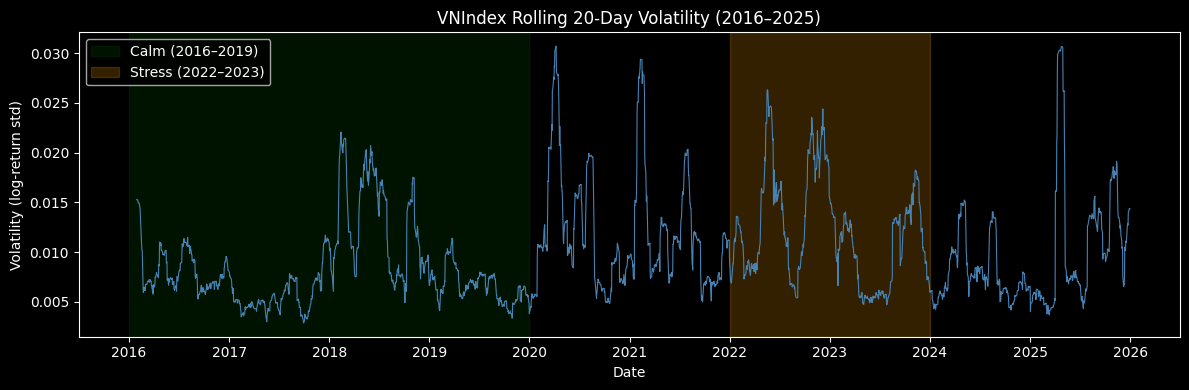


Regime distribution (weeks):
regime
calm      207
other     204
stress    103
Name: n_weeks, dtype: int64
Saved: regime_labels.csv


In [12]:
# Compute 20-day rolling volatility as a proxy for market stress
df_vnx = pd.read_csv("vnindex_clean.csv")
df_vnx["date"] = pd.to_datetime(df_vnx["date"])
df_vnx = df_vnx.sort_values("date")
df_vnx = df_vnx[(df_vnx["date"] >= "2016-01-01") & (df_vnx["date"] <= "2025-12-31")]

# vnindex is the cleaned index level saved by notebook 1
df_vnx["ret"]     = np.log(df_vnx["vnindex"] / df_vnx["vnindex"].shift(1))
df_vnx["vol_20d"] = df_vnx["ret"].rolling(20).std()
df_vnx = df_vnx.dropna(subset=["vol_20d"])

calm   = df_vnx.loc[(df_vnx["date"] >= CALM_START) & (df_vnx["date"] <= CALM_END), "vol_20d"]
stress = df_vnx.loc[(df_vnx["date"] >= STRESS_START) & (df_vnx["date"] <= STRESS_END), "vol_20d"]

# Welch t-test (unequal variance) + KS test to confirm the two distributions differ
t_stat,  p_val_t  = stats.ttest_ind(calm, stress, equal_var=False)
ks_stat, p_val_ks = stats.ks_2samp(calm, stress)

print(f"Calm   mean vol: {calm.mean():.6f}  (n={len(calm)})")
print(f"Stress mean vol: {stress.mean():.6f}  (n={len(stress)})")
print(f"\nWelch t-test p : {p_val_t:.2e}")
print(f"KS test p      : {p_val_ks:.2e}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_vnx["date"], df_vnx["vol_20d"], linewidth=0.8, color="steelblue")
ax.axvspan(pd.Timestamp(CALM_START), pd.Timestamp(CALM_END),
           alpha=0.15, color="green", label="Calm (2016–2019)")
ax.axvspan(pd.Timestamp(STRESS_START), pd.Timestamp(STRESS_END),
           alpha=0.20, color="orange", label="Stress (2022–2023)")
ax.set_title("VNIndex Rolling 20-Day Volatility (2016–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (log-return std)")
ax.legend()
plt.tight_layout()
plt.savefig("regime_volatility.png", dpi=150)
plt.show()

predictions["regime"] = assign_regime(predictions["date"])

print("\nRegime distribution (weeks):")
print(predictions.groupby("regime")["date"].nunique().rename("n_weeks"))

regime_labels = (
    predictions[["date", "regime"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)
regime_labels.to_csv("regime_labels.csv", index=False)
print("Saved: regime_labels.csv")

## 3.10 H4: ML vs FE Performance by Market Regime

Using the predictions from Section 3.5 and the regime labels from Section 3.9,
OOS R² is computed for each model (Block 3) within each regime.

**H4:** The predictive advantage of tree-based machine learning models over the linear fixed-effects benchmark is smaller during stress regimes than during calm regimes.

In [13]:
print("H4: ML vs FE BY REGIME")

# ML advantage over FE within each regime (OOS R² difference)
h4_results = []

# Full OOS mean as benchmark — consistent with full-sample OOS R² definition
# (Gu et al. 2020 convention: benchmark = unconditional OOS mean, same across all regimes)
full_oos_mean = predictions["actual"].mean()

# Evaluate model performance separately for each regime (H4 test)
for regime in ["calm", "stress", "other"]:
    sub = predictions[predictions["regime"] == regime]
    n_weeks = sub["date"].nunique()
    n_obs   = len(sub)
    print(f"\nRegime: {regime} | weeks: {n_weeks} | obs: {n_obs:,}")

    # Compare FE vs RF vs XGB within each regime
    for model_name, pred_col in [
        ("FE",  "pred_fe_b3"),
        ("RF",  "pred_rf_b3"),
        ("XGB", "pred_xgb_b3"),
    ]:
        actual    = sub["actual"].values
        predicted = sub[pred_col].values

        sse_model = np.sum((actual - predicted) ** 2)
        sse_bench = np.sum((actual - full_oos_mean) ** 2)
        r2   = 1 - sse_model / sse_bench
        mae  = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        h4_results.append({
            "regime":  regime,
            "model":   model_name,
            "oos_r2":  r2,
            "mae":     mae,
            "rmse":    rmse,
            "n_weeks": n_weeks,
            "n_obs":   n_obs,
        })
        print(f"  {model_name}: OOS R\u00b2 = {r2:.4f}")

h4_df = pd.DataFrame(h4_results)
h4_df.to_csv("h4_regime_results.csv", index=False)

# ML advantage = (RF or XGB OOS R²) minus (FE OOS R²) within the same regime
fe_r2 = h4_df[h4_df["model"] == "FE"][["regime", "oos_r2"]].rename(columns={"oos_r2": "fe_r2"})
h4_adv = h4_df[h4_df["model"] != "FE"].merge(fe_r2, on="regime")
h4_adv["ml_advantage"] = h4_adv["oos_r2"] - h4_adv["fe_r2"]
h4_adv.to_csv("h4_regime_advantage.csv", index=False)

print("\nML advantage over FE (OOS R\u00b2 gap) by regime:")
print(h4_adv[["regime", "model", "oos_r2", "fe_r2", "ml_advantage"]].to_string(index=False))
print("\nSaved: h4_regime_results.csv, h4_regime_advantage.csv")


H4: ML vs FE BY REGIME

Regime: calm | weeks: 207 | obs: 36,520
  FE: OOS R² = -0.0171
  RF: OOS R² = -0.0018
  XGB: OOS R² = -0.0022

Regime: stress | weeks: 103 | obs: 20,754
  FE: OOS R² = -0.0001
  RF: OOS R² = -0.0003
  XGB: OOS R² = -0.0009

Regime: other | weeks: 204 | obs: 40,702
  FE: OOS R² = -0.0039
  RF: OOS R² = 0.0013
  XGB: OOS R² = 0.0013

ML advantage over FE (OOS R² gap) by regime:
regime model    oos_r2     fe_r2  ml_advantage
  calm    RF -0.001794 -0.017070      0.015276
  calm   XGB -0.002198 -0.017070      0.014871
stress    RF -0.000289 -0.000062     -0.000226
stress   XGB -0.000877 -0.000062     -0.000815
 other    RF  0.001306 -0.003857      0.005163
 other   XGB  0.001324 -0.003857      0.005181

Saved: h4_regime_results.csv, h4_regime_advantage.csv


## 3.11 SHAP Analysis (XGB Block 3)

Block 3 is used rather than B1 or B2 because it contains the full feature set across all three groups (baseline, liquidity, foreign flow), which is needed to analyze feature contributions for H3a and H4a. Among the Block 3 models, XGB achieves the best OOS R² (XGB: -0.0010, RF: -0.0018, FE: -0.0104), so it is selected for S analysis.

The expanding window is re-run here to obtain fitted model objects at each OOS week. SHAP values are computed using TreeExplainer, which gives exact Shapley values for tree-based models. Regime labels are attached to the output so that Notebook 4 can compare feature importance across calm and stress periods.

In [14]:
print("SHAP: OOS XGB Block 3")

# Re-estimate XGB (Block 3) to obtain fitted models for SHAP computation
all_shap = []

# Expanding window: train on observations before week t, predict week t, then compute SHAP values
for i, current_date in enumerate(oos_dates):
    train_df = df[df["date"] < current_date]
    test_df  = df[df["date"] == current_date]

    X_train = train_df[block3_features]
    y_train = train_df[TARGET_COL]
    X_test  = test_df[block3_features]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        **best_xgb_params["b3"]
    )
    model.fit(X_train, y_train)

    # Compute SHAP values for current OOS predictions
    explainer = shap.TreeExplainer(model)
    shap_explanation = explainer(X_test)
    shap_vals = shap_explanation.values  # shape: (n_test_rows, n_features)

    shap_df = pd.DataFrame(shap_vals, columns=block3_features)
    shap_df["ticker"] = test_df["ticker"].values
    shap_df["date"]   = test_df["date"].values
    all_shap.append(shap_df)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(oos_dates)}] done")

shap_xgb_b3 = pd.concat(all_shap, ignore_index=True)

# Attach regime so notebook 4 can compare feature importance across calm vs stress
shap_xgb_b3["regime"] = assign_regime(shap_xgb_b3["date"])
shap_xgb_b3.to_csv("shap_xgb_b3.csv", index=False)

print(f"\nSHAP table shape: {shap_xgb_b3.shape}")
print("Saved: shap_xgb_b3.csv")

SHAP: OOS XGB Block 3
  [100/514] done
  [200/514] done
  [300/514] done
  [400/514] done
  [500/514] done

SHAP table shape: (97976, 12)
Saved: shap_xgb_b3.csv


## 3.12 SHAP Analysis (RF Block 3)

Random Forest Block 3 SHAP computed alongside XGB for comparison. The model used for primary SHAP analysis in the thesis will be determined after the full rerun, based on which tree-based model achieves higher OOS R² on Block 3.

In [15]:
print("SHAP: OOS RF Block 3")

# Re-estimate RF (Block 3) to obtain fitted models for SHAP computation
all_shap_rf = []

# Expanding window: train on observations before week t, predict week t, then compute SHAP values
for i, current_date in enumerate(oos_dates):
    train_df = df[df["date"] < current_date]
    test_df  = df[df["date"] == current_date]

    X_train = train_df[block3_features]
    y_train = train_df[TARGET_COL]
    X_test  = test_df[block3_features]

    model_rf = RandomForestRegressor(
        n_jobs=-1,
        **best_rf_params["b3"]
    )
    model_rf.fit(X_train, y_train)

    # Compute SHAP values for current OOS predictions
    explainer_rf = shap.TreeExplainer(model_rf)
    shap_explanation_rf = explainer_rf(X_test)
    shap_vals_rf = shap_explanation_rf.values  # shape: (n_test_rows, n_features)

    shap_df_rf = pd.DataFrame(shap_vals_rf, columns=block3_features)
    shap_df_rf["ticker"] = test_df["ticker"].values
    shap_df_rf["date"]   = test_df["date"].values
    all_shap_rf.append(shap_df_rf)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(oos_dates)}] done")

shap_rf_b3 = pd.concat(all_shap_rf, ignore_index=True)

# Attach regime so notebook 4 can compare feature importance across calm vs stress
shap_rf_b3["regime"] = assign_regime(shap_rf_b3["date"])
shap_rf_b3.to_csv("shap_rf_b3.csv", index=False)

print(f"\nSHAP table shape: {shap_rf_b3.shape}")
print("Saved: shap_rf_b3.csv")

SHAP: OOS RF Block 3
  [100/514] done
  [200/514] done
  [300/514] done
  [400/514] done
  [500/514] done

SHAP table shape: (97976, 12)
Saved: shap_rf_b3.csv
